<a href="https://colab.research.google.com/github/joaocanaslopes/AV_project-/blob/main/Analises_prodvsclima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("https://raw.githubusercontent.com/joaocanaslopes/AV_project-/refs/heads/main/final_table.csv")
df.head()

,year,region,species,area_ha,production_t,productivity_kg_ha,irrigable_area_ha,precipitation_mm,mean_temp,mean_tmax,mean_tmin,annual_precipitation_anomaly
0,2018,Alentejo,Cereais para grão,99278.0,369821.0,3725.105260,175410.0,570.0,16.59,22.610833,10.57,43.55
1,2018,Alentejo,Trigo,18631.0,47839.0,2567.709731,175410.0,570.0,16.59,22.610833,10.57,43.55
2,2018,Alentejo,Trigo mole,14677.0,37133.0,2530.012945,175410.0,570.0,16.59,22.610833,10.57,43.55
3,2018,Alentejo,Trigo duro,3955.0,10706.0,2706.953224,175410.0,570.0,16.59,22.610833,10.57,43.55
4,2018,Alentejo,Centeio,112.0,134.0,1196.428571,175410.0,570.0,16.59,22.610833,10.57,43.55


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2632 entries, 0 to 2631
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          2632 non-null   int64  
 1   region                        2632 non-null   object 
 2   species                       2632 non-null   object 
 3   area_ha                       2632 non-null   float64
 4   production_t                  2632 non-null   float64
 5   productivity_kg_ha            2632 non-null   float64
 6   irrigable_area_ha             2632 non-null   float64
 7   precipitation_mm              2632 non-null   float64
 8   mean_temp                     2632 non-null   float64
 9   mean_tmax                     2632 non-null   float64
 10  mean_tmin                     2632 non-null   float64
 11  annual_precipitation_anomaly  2632 non-null   float64
dtypes: float64(9), int64(1), object(2)
memory usage: 246.9+ KB


### Análise de Séries Temporais: Produção e Fatores Climáticos por Região

Para entender a evolução da produtividade agrícola em relação à disponibilidade de água e temperatura, vamos visualizar as tendências anuais da produção total, precipitação e temperatura média para as regiões do Alentejo e Algarve.

In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Agrupar dados por ano e região para obter a produção total, precipitação média e temperatura média
df_yearly_region = df.groupby(['year', 'region']).agg(
    total_production_t=('production_t', 'sum'),
    avg_precipitation_mm=('precipitation_mm', 'mean'),
    avg_mean_temp=('mean_temp', 'mean')
).reset_index()

regions = df_yearly_region['region'].unique()

for region in regions:
    df_region = df_yearly_region[df_yearly_region['region'] == region]

    fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                        subplot_titles=(
                            f'Produção Total Anual em {region}',
                            f'Precipitação Média Anual em {region}',
                            f'Temperatura Média Anual em {region}'
                        ))

    # Plot 1: Produção Total
    fig.add_trace(go.Scatter(x=df_region['year'], y=df_region['total_production_t'], mode='lines+markers', name='Produção Total'),
                  row=1, col=1)
    fig.update_yaxes(title_text='Produção Total (toneladas)', row=1, col=1)

    # Plot 2: Precipitação Média
    fig.add_trace(go.Scatter(x=df_region['year'], y=df_region['avg_precipitation_mm'], mode='lines+markers', name='Precipitação Média', line=dict(color='blue')),
                  row=2, col=1)
    fig.update_yaxes(title_text='Precipitação (mm)', row=2, col=1)

    # Plot 3: Temperatura Média
    fig.add_trace(go.Scatter(x=df_region['year'], y=df_region['avg_mean_temp'], mode='lines+markers', name='Temperatura Média', line=dict(color='red')),
                  row=3, col=1)
    fig.update_yaxes(title_text='Temperatura Média (°C)', row=3, col=1)

    fig.update_layout(title_text=f'Tendências Anuais de Produção e Clima: {region}', height=700, showlegend=False)
    fig.show()

# Produção total por região

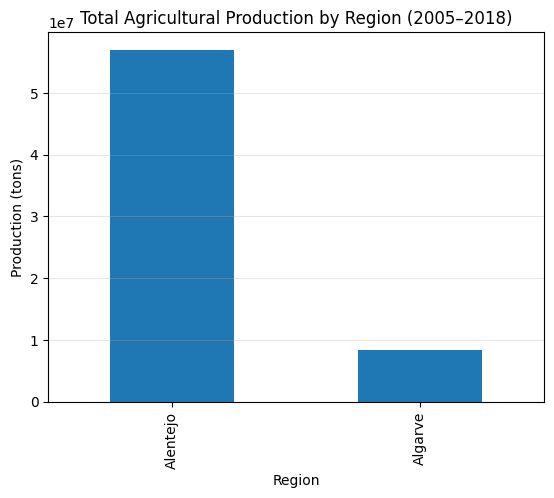

In [6]:
import matplotlib.pyplot as plt

df.groupby("region")["production_t"].sum().plot(kind="bar")

plt.title("Total Agricultural Production by Region (2005–2018)")
plt.xlabel("Region")
plt.ylabel("Production (tons)")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Area cultivada por região

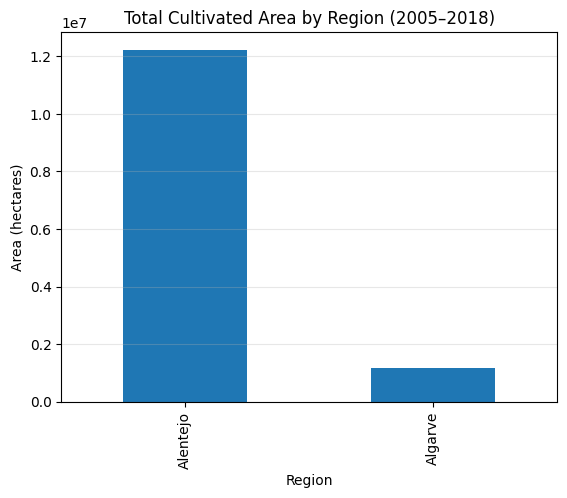

In [7]:
df.groupby("region")["area_ha"].sum().plot(kind="bar")

plt.title("Total Cultivated Area by Region (2005–2018)")
plt.xlabel("Region")
plt.ylabel("Area (hectares)")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Chuva vs produtividade

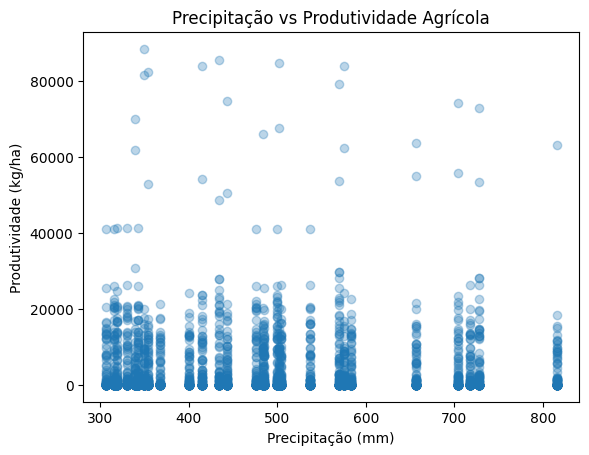

In [8]:
plt.scatter(
    df["precipitation_mm"],
    df["productivity_kg_ha"],
    alpha=0.3
)

plt.xlabel("Precipitação (mm)")
plt.ylabel("Produtividade (kg/ha)")
plt.title("Precipitação vs Produtividade Agrícola")
plt.show()

# Temperatura vs produtividade

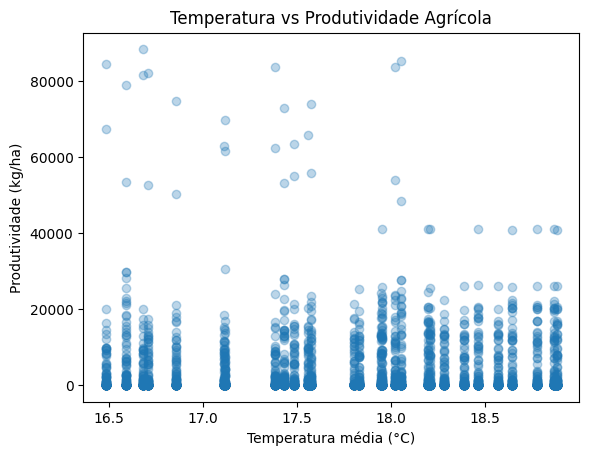

In [9]:
plt.scatter(
    df["mean_temp"],
    df["productivity_kg_ha"],
    alpha=0.3
)

plt.xlabel("Temperatura média (°C)")
plt.ylabel("Produtividade (kg/ha)")
plt.title("Temperatura vs Produtividade Agrícola")
plt.show()

### Análise focada nas regiões do Algarve e Alentejo

#### Relação entre Precipitação anomalia e temperatura com a Produtividade Agrícola nas Regiões do Alentejo e Algarve

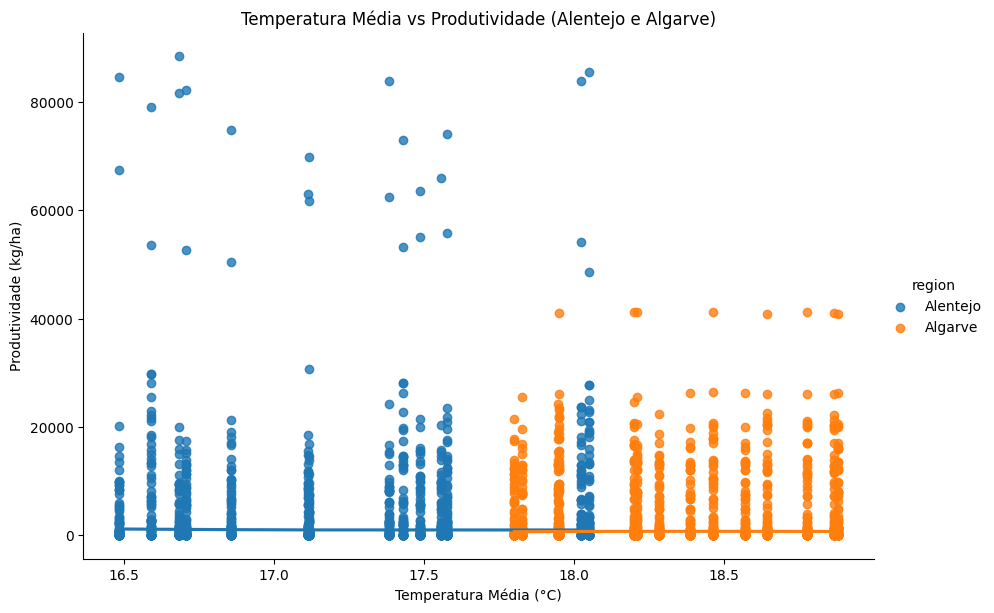

In [10]:
sns.lmplot(
    data=df,
    x="mean_temp",
    y="productivity_kg_ha",
    hue="region",
    lowess=True,
    aspect=1.5, # Ajusta a proporção do gráfico
    height=6
)
plt.title("Temperatura Média vs Produtividade (Alentejo e Algarve)")
plt.xlabel("Temperatura Média (°C)")
plt.ylabel("Produtividade (kg/ha)")
plt.show()

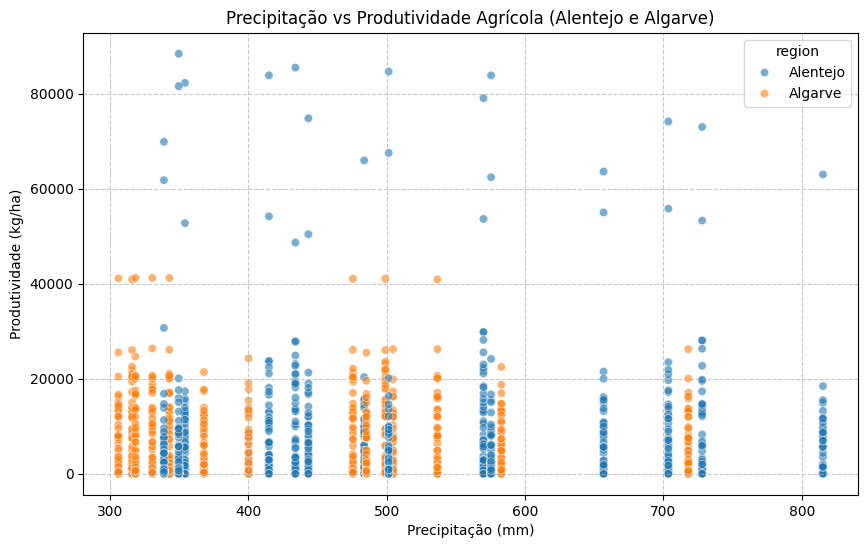

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="precipitation_mm",
    y="productivity_kg_ha",
    hue="region",
    alpha=0.6
)
plt.title("Precipitação vs Produtividade Agrícola (Alentejo e Algarve)")
plt.xlabel("Precipitação (mm)")
plt.ylabel("Produtividade (kg/ha)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

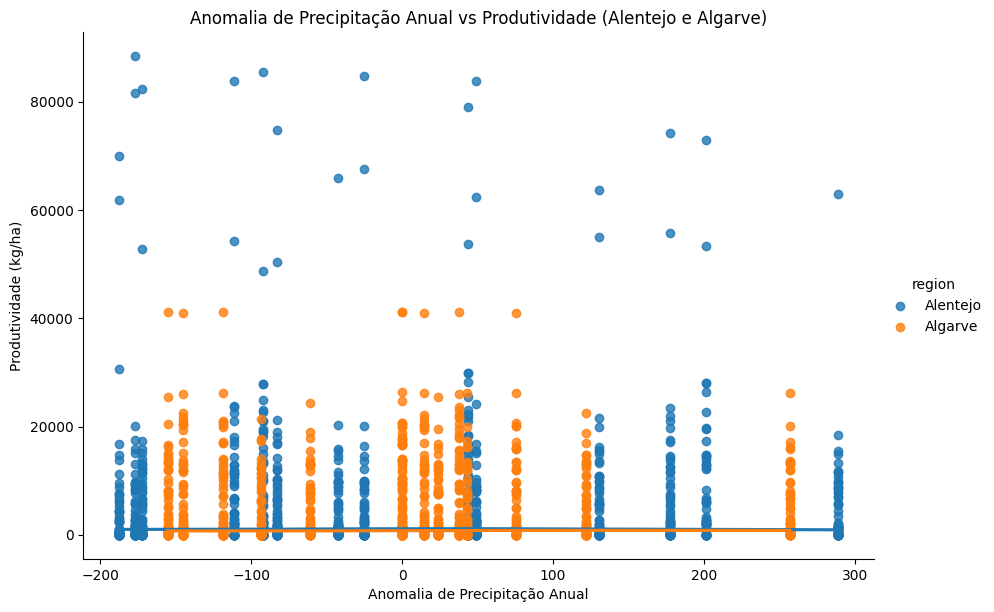

In [12]:
sns.lmplot(
    data=df,
    x="annual_precipitation_anomaly",
    y="productivity_kg_ha",
    hue="region",
    lowess=True,
    aspect=1.5, # Ajusta a proporção do gráfico
    height=6
)
plt.title("Anomalia de Precipitação Anual vs Produtividade (Alentejo e Algarve)")
plt.xlabel("Anomalia de Precipitação Anual")
plt.ylabel("Produtividade (kg/ha)")
plt.show()

#### Relação entre Área Irrigável e Produtividade Agrícola nas Regiões do Alentejo e Algarve

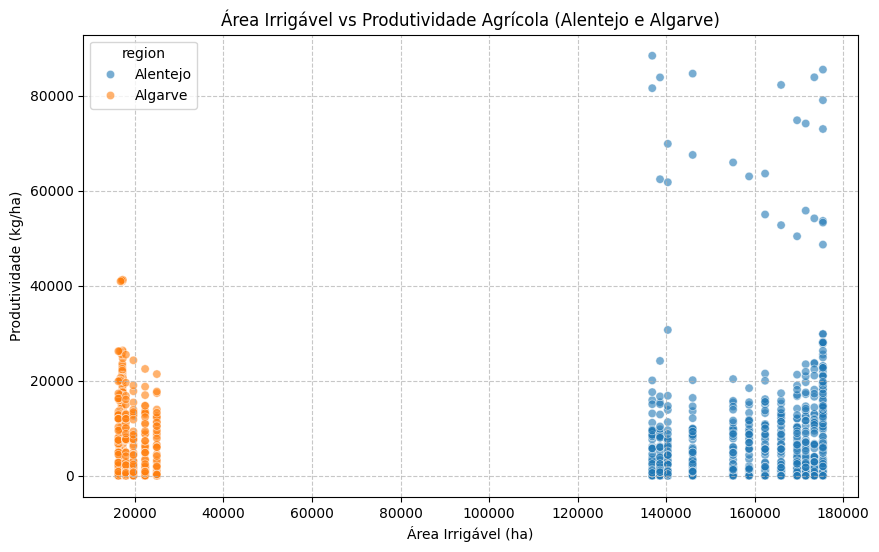

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="irrigable_area_ha",
    y="productivity_kg_ha",
    hue="region",
    alpha=0.6
)
plt.title("Área Irrigável vs Produtividade Agrícola (Alentejo e Algarve)")
plt.xlabel("Área Irrigável (ha)")
plt.ylabel("Produtividade (kg/ha)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Correlação entre Variáveis Chave para Alentejo e Algarve

In [14]:
# Calcular a correlação entre as variáveis de interesse
correlation_matrix = df[['precipitation_mm', 'irrigable_area_ha', 'productivity_kg_ha', 'mean_temp']].corr()

print("Matriz de Correlação para Alentejo e Algarve:")
display(correlation_matrix)

Matriz de Correlação para Alentejo e Algarve:


,precipitation_mm,irrigable_area_ha,productivity_kg_ha,mean_temp
precipitation_mm,1.000000,0.328570,0.001640,-0.154101
irrigable_area_ha,0.328570,1.000000,0.045560,-0.766139
productivity_kg_ha,0.001640,0.045560,1.000000,-0.017236
mean_temp,-0.154101,-0.766139,-0.017236,1.000000


Podemos também visualizar as correlações usando um mapa de calor (`heatmap`).

## Heatmap de correlações

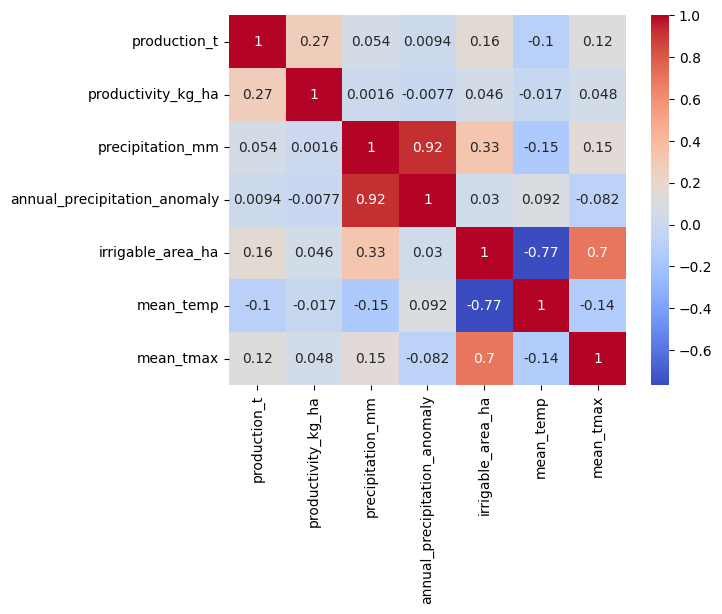

In [15]:
corr_vars = df[
    [
        "production_t",
        "productivity_kg_ha",
        "precipitation_mm",
        "annual_precipitation_anomaly",
        "irrigable_area_ha",
        "mean_temp",
        "mean_tmax"
    ]
]

corr = corr_vars.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

# Hovers

In [16]:
import plotly.express as px

fig = px.scatter(
    df,
    x="mean_temp",
    y="productivity_kg_ha",
    color="region",
    title="Temperatura Média vs Produtividade (Alentejo e Algarve) com Interatividade",
    labels={
        "mean_temp": "Temperatura Média (°C)",
        "productivity_kg_ha": "Produtividade (kg/ha)"
    },
    hover_data=[ # Adiciona as informações que aparecerão no hover
        'year',
        'region',
        'species',
        'area_ha',
        'production_t',
        'precipitation_mm',
        'irrigable_area_ha',
        'annual_precipitation_anomaly'
    ]
)

# Adicionar uma linha de regressão (opcional, Plotly Express pode fazer isso com trendline)
fig.update_traces(mode='markers', marker_size=8, opacity=0.7)
fig.update_layout(
    hovermode="closest", # Melhora a experiência do hover
    height=600 # Ajusta a altura do gráfico
)

# Adicionar linha de regressão usando o parâmetro trendline
fig = px.scatter(
    df,
    x="mean_temp",
    y="productivity_kg_ha",
    color="region",
    trendline="ols", # Adiciona uma linha de regressão OLS (Ordinary Least Squares)
    title="Temperatura Média vs Produtividade (Alentejo e Algarve) com Interatividade e Regressão",
    labels={
        "mean_temp": "Temperatura Média (°C)",
        "productivity_kg_ha": "Produtividade (kg/ha)"
    },
    hover_data=[ # Adiciona as informações que aparecerão no hover
        'year',
        'region',
        'species',
        'area_ha',
        'production_t',
        'precipitation_mm',
        'irrigable_area_ha',
        'annual_precipitation_anomaly'
    ]
)
fig.show()

In [17]:
import plotly.express as px

fig_precip = px.scatter(
    df,
    x="precipitation_mm",
    y="productivity_kg_ha",
    color="region",
    trendline="ols", # Adiciona uma linha de regressão OLS (Ordinary Least Squares)
    title="Precipitação vs Produtividade (Alentejo e Algarve) com Interatividade e Regressão",
    labels={
        "precipitation_mm": "Precipitação (mm)",
        "productivity_kg_ha": "Produtividade (kg/ha)"
    },
    hover_data=[ # Adiciona as informações que aparecerão no hover
        'year',
        'region',
        'species',
        'area_ha',
        'production_t',
        'precipitation_mm',
        'irrigable_area_ha',
        'annual_precipitation_anomaly'
    ]
)
fig_precip.show()

In [18]:
import plotly.express as px

fig_anomaly = px.scatter(
    df,
    x="annual_precipitation_anomaly",
    y="productivity_kg_ha",
    color="region",
    trendline="ols", # Adiciona uma linha de regressão OLS (Ordinary Least Squares)
    title="Anomalia de Precipitação Anual vs Produtividade (Alentejo e Algarve) com Interatividade e Regressão",
    labels={
        "annual_precipitation_anomaly": "Anomalia de Precipitação Anual",
        "productivity_kg_ha": "Produtividade (kg/ha)"
    },
    hover_data=[ # Adiciona as informações que aparecerão no hover
        'year',
        'region',
        'species',
        'area_ha',
        'production_t',
        'precipitation_mm',
        'irrigable_area_ha',
        'annual_precipitation_anomaly'
    ]
)
fig_anomaly.show()

In [19]:
import plotly.express as px

fig_temp_prod = px.scatter(
    df,
    x="mean_temp",
    y="production_t",
    color="region",
    trendline="ols", # Adiciona uma linha de regressão OLS (Ordinary Least Squares)
    title="Temperatura Média vs Produção Total (Alentejo e Algarve) com Interatividade e Regressão",
    labels={
        "mean_temp": "Temperatura Média (°C)",
        "production_t": "Produção Total (toneladas)"
    },
    hover_data=[ # Adiciona as informações que aparecerão no hover
        'year',
        'region',
        'species',
        'area_ha',
        'production_t',
        'precipitation_mm',
        'irrigable_area_ha',
        'annual_precipitation_anomaly',
        'productivity_kg_ha'
    ]
)
fig_temp_prod.show()

In [20]:
import plotly.express as px

fig_precip_prod = px.scatter(
    df,
    x="precipitation_mm",
    y="production_t",
    color="region",
    trendline="ols", # Adiciona uma linha de regressão OLS (Ordinary Least Squares)
    title="Precipitação vs Produção Total (Alentejo e Algarve) com Interatividade e Regressão",
    labels={
        "precipitation_mm": "Precipitação (mm)",
        "production_t": "Produção Total (toneladas)"
    },
    hover_data=[ # Adiciona as informações que aparecerão no hover
        'year',
        'region',
        'species',
        'area_ha',
        'production_t',
        'precipitation_mm',
        'irrigable_area_ha',
        'annual_precipitation_anomaly',
        'productivity_kg_ha'
    ]
)
fig_precip_prod.show()

In [21]:
import plotly.express as px

fig_anomaly_prod = px.scatter(
    df,
    x="annual_precipitation_anomaly",
    y="production_t",
    color="region",
    trendline="ols", # Adiciona uma linha de regressão OLS (Ordinary Least Squares)
    title="Anomalia de Precipitação Anual vs Produção Total (Alentejo e Algarve) com Interatividade e Regressão",
    labels={
        "annual_precipitation_anomaly": "Anomalia de Precipitação Anual",
        "production_t": "Produção Total (toneladas)"
    },
    hover_data=[ # Adiciona as informações que aparecerão no hover
        'year',
        'region',
        'species',
        'area_ha',
        'production_t',
        'precipitation_mm',
        'irrigable_area_ha',
        'annual_precipitation_anomaly',
        'productivity_kg_ha'
    ]
)
fig_anomaly_prod.show()

### Análise do Impacto da Capacidade de Irrigação

Agora vamos explorar a relação entre a `irrigable_area_ha` (capacidade de irrigação) e a `production_t` (produção total) ou `productivity_kg_ha` (produtividade por hectare). Podemos visualizar isso para as duas regiões para ver se a capacidade de irrigação tem um impacto diferente em cada uma.

In [22]:
import plotly.express as px

# Plot para Irrigação vs Produtividade
fig_irr_prod = px.scatter(
    df,
    x="irrigable_area_ha",
    y="productivity_kg_ha",
    color="region",
    trendline="ols",
    title="Área Irrigável vs Produtividade Agrícola (Alentejo e Algarve)",
    labels={
        "irrigable_area_ha": "Área Irrigável (hectares)",
        "productivity_kg_ha": "Produtividade (kg/ha)"
    },
    hover_data=['year', 'region', 'species', 'production_t', 'mean_temp', 'precipitation_mm', 'annual_precipitation_anomaly']
)
fig_irr_prod.show()

# Plot para Irrigação vs Produção Total
fig_irr_total_prod = px.scatter(
    df,
    x="irrigable_area_ha",
    y="production_t",
    color="region",
    trendline="ols",
    title="Área Irrigável vs Produção Total (Alentejo e Algarve)",
    labels={
        "irrigable_area_ha": "Área Irrigável (hectares)",
        "production_t": "Produção Total (toneladas)"
    },
    hover_data=['year', 'region', 'species', 'production_t', 'mean_temp', 'precipitation_mm', 'annual_precipitation_anomaly']
)
fig_irr_total_prod.show()

### Análise de Correlação: Espécies Agrícolas e Fatores Climáticos

Com o objetivo de identificar as espécies agrícolas mais suscetíveis às anomalias de precipitação, escassez de água (baixa precipitação) e excesso de calor (alta temperatura), realizamos uma análise de correlação entre a produção total (`production_t`) de cada espécie e as seguintes variáveis climáticas:

*   **`annual_precipitation_anomaly`**: Anomalia de precipitação anual.
*   **`precipitation_mm`**: Precipitação total em milímetros.
*   **`mean_temp`**: Temperatura média.

**Interpretação das Correlações:**

*   **Correlação Positiva (+)**: Indica que, à medida que a variável climática aumenta, a produção total da espécie tende a aumentar. Por exemplo, uma alta correlação positiva com `precipitation_mm` sugere que a espécie se beneficia de mais chuva.
*   **Correlação Negativa (-)**: Indica que, à medida que a variável climática aumenta, a produção total da espécie tende a diminuir. Por exemplo, uma alta correlação negativa com `mean_temp` sugere que a espécie é sensível ao calor excessivo, com sua produção sendo reduzida em temperaturas mais altas.
*   **Magnitude da Correlação**: Quanto mais próximo o valor absoluto da correlação estiver de 1 (seja 1 ou -1), mais forte é a relação entre as variáveis. Valores próximos de 0 indicam uma relação fraca ou inexistente.

**Sumário dos Resultados:**

Identificamos as 5 espécies com as maiores e menores correlações (positivas e negativas) para cada fator climático, o que nos permite entender quais espécies são mais vulneráveis ou beneficiadas pelas variações climáticas no Alentejo e Algarve.

**Top 5 espécies mais afetadas positivamente por Anomalia de Precipitação Anual (maior produção com maior anomalia/chuva):**

*   `Trigo duro` (0.299895)
*   `Aveia` (0.166888)
*   `Milho forrageiro` (0.155021)
*   `Triticale` (0.126015)
*   `Milho sequeiro` (0.115966)

**Top 5 espécies mais afetadas negativamente por Anomalia de Precipitação Anual (menor produção com maior anomalia/seca):**

*   `Beterraba` (-0.293802)
*   `Batata` (-0.259316)
*   `Batata de regadio` (-0.249596)
*   `Batata de sequeiro` (-0.230803)
*   `Tabaco` (-0.203229)

**Top 5 espécies mais afetadas positivamente por Precipitação Total (maior produção com mais chuva):**

*   `Trigo duro` (0.494250)
*   `Aveia` (0.427909)
*   `Triticale` (0.385534)
*   `Vinha` (0.383226)
*   `Uva para vinho` (0.382034)

**Top 5 espécies mais afetadas negativamente por Precipitação Total (menor produção com mais chuva):**

*   `Toranja` (-0.343490)
*   `Diospiro` (-0.343490)
*   `Laranja` (-0.329337)
*   `Citrinos` (-0.329337)
*   `Nespera` (-0.305168)

**Top 5 espécies mais afetadas positivamente por Temperatura Média (maior produção com mais calor):**

*   `Diospiro` (0.822472)
*   `Figo` (0.815608)
*   `Citrinos` (0.788394)
*   `Nespera` (0.787658)
*   `Laranja` (0.786932)

**Top 5 espécies mais afetadas negativamente por Temperatura Média (menor produção com mais calor):**

*   `Maçã` (-0.791071)
*   `Arroz` (-0.791071)
*   `Cereais para grão` (-0.773453)
*   `Uva para vinho` (-0.759311)
*   `Vinha` (-0.757108)

Estes resultados fornecem uma base para identificar as espécies mais vulneráveis ou beneficiadas pelas condições climáticas extremas no Sul de Portugal, e podem guiar futuras análises sobre estratégias de adaptação ou mitigação.

In [23]:
# Calculate correlations for each species
species_correlations = {}

for species in df['species'].unique():
    df_species = df[df['species'] == species]

    # Ensure there's enough data to calculate correlation
    if len(df_species) > 1:
        corr_precip_anomaly_prod = df_species['annual_precipitation_anomaly'].corr(df_species['production_t'])
        corr_precip_prod = df_species['precipitation_mm'].corr(df_species['production_t'])
        corr_temp_prod = df_species['mean_temp'].corr(df_species['production_t'])

        species_correlations[species] = {
            'corr_annual_precip_anomaly_prod': corr_precip_anomaly_prod,
            'corr_precipitation_mm_prod': corr_precip_prod,
            'corr_mean_temp_prod': corr_temp_prod
        }

# Convert to DataFrame for better visualization
corr_df = pd.DataFrame.from_dict(species_correlations, orient='index')

print("Correlações entre variáveis climáticas e produção total por espécie:")
display(corr_df.head(10)) # Display top 10 species by correlation

Correlações entre variáveis climáticas e produção total por espécie:


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



,corr_annual_precip_anomaly_prod,corr_precipitation_mm_prod,corr_mean_temp_prod
Cereais para grão,0.040599,0.326435,-0.773453
Trigo,0.046755,0.274147,-0.645042
Trigo mole,0.020283,0.240803,-0.629687
Trigo duro,0.299895,0.494250,-0.508383
Centeio,0.061631,0.332778,-0.627565
Aveia,0.166888,0.427909,-0.740780
Cevada,-0.012751,0.233043,-0.675680
Triticale,0.126015,0.385534,-0.674142
Milho,-0.013073,0.253401,-0.697664
Milho regadio,-0.013117,0.253375,-0.697678


Agora que temos as correlações, podemos identificar as espécies mais afetadas. Uma correlação positiva alta com 'annual_precipitation_anomaly' ou 'precipitation_mm' pode indicar dependência de água, enquanto uma correlação negativa alta com 'mean_temp' pode indicar sensibilidade ao calor excessivo, ou vice-versa, dependendo do sinal.

Vamos focar nas espécies com as maiores magnitudes de correlação para cada variável climática.

In [24]:
# Identify species most affected by precipitation anomaly (positive and negative)
most_affected_precip_anomaly_pos = corr_df.nlargest(5, 'corr_annual_precip_anomaly_prod')
most_affected_precip_anomaly_neg = corr_df.nsmallest(5, 'corr_annual_precip_anomaly_prod')

print("Top 5 espécies mais afetadas positivamente por Anomalia de Precipitação Anual (maior produção com maior anomalia):")
display(most_affected_precip_anomaly_pos)

print("\nTop 5 espécies mais afetadas negativamente por Anomalia de Precipitação Anual (menor produção com maior anomalia):")
display(most_affected_precip_anomaly_neg)

# Identify species most affected by total precipitation (water scarcity)
most_affected_precip_pos = corr_df.nlargest(5, 'corr_precipitation_mm_prod')
most_affected_precip_neg = corr_df.nsmallest(5, 'corr_precipitation_mm_prod')

print("\nTop 5 espécies mais afetadas positivamente por Precipitação Total (maior produção com mais chuva):")
display(most_affected_precip_pos)

print("\nTop 5 espécies mais afetadas negativamente por Precipitação Total (menor produção com mais chuva):")
display(most_affected_precip_neg)

# Identify species most affected by mean temperature (heat)
most_affected_temp_pos = corr_df.nlargest(5, 'corr_mean_temp_prod')
most_affected_temp_neg = corr_df.nsmallest(5, 'corr_mean_temp_prod')

print("\nTop 5 espécies mais afetadas positivamente por Temperatura Média (maior produção com mais calor):")
display(most_affected_temp_pos)

print("\nTop 5 espécies mais afetadas negativamente por Temperatura Média (menor produção com mais calor):")
display(most_affected_temp_neg)

# Summarize findings as requested by the user
print("\n--- Resumo das Espécies Mais Afetadas ---")
print("\n1. Espécies com MENOS PRODUÇÃO com MAIS TEMPERATURA (correlação negativa com mean_temp):")
display(most_affected_temp_neg)

print("\n2. Espécies com MENOS PRODUÇÃO com MENOS CHUVA (correlação positiva com precipitation_mm):")
display(most_affected_precip_pos)

print("\n3. Espécies com MENOS PRODUÇÃO com ANOMALIAS DE PRECIPITAÇÃO MENORES (correlação positiva com annual_precipitation_anomaly):")
display(most_affected_precip_anomaly_pos)

Top 5 espécies mais afetadas positivamente por Anomalia de Precipitação Anual (maior produção com maior anomalia):


,corr_annual_precip_anomaly_prod,corr_precipitation_mm_prod,corr_mean_temp_prod
Trigo duro,0.299895,0.494250,-0.508383
Aveia,0.166888,0.427909,-0.740780
Milho forrageiro,0.155021,0.303834,-0.334917
Triticale,0.126015,0.385534,-0.674142
Milho sequeiro,0.115966,-0.083955,0.449756



Top 5 espécies mais afetadas negativamente por Anomalia de Precipitação Anual (menor produção com maior anomalia):


,corr_annual_precip_anomaly_prod,corr_precipitation_mm_prod,corr_mean_temp_prod
Beterraba,-0.293802,-0.170882,-0.326347
Batata,-0.259316,-0.147654,-0.342513
Batata de regadio,-0.249596,-0.142204,-0.302046
Batata de sequeiro,-0.230803,-0.131128,-0.389577
Tabaco,-0.203229,-0.046901,-0.442455



Top 5 espécies mais afetadas positivamente por Precipitação Total (maior produção com mais chuva):


...

,corr_annual_precip_anomaly_prod,corr_precipitation_mm_prod,corr_mean_temp_prod
Maçã,-0.108841,0.188527,-0.791154
Arroz,0.021558,0.320054,-0.791071
Cereais para grão,0.040599,0.326435,-0.773453
Uva para vinho,0.092249,0.382034,-0.759311
Vinha,0.093455,0.383226,-0.757108



2. Espécies com MENOS PRODUÇÃO com MENOS CHUVA (correlação positiva com precipitation_mm):


,corr_annual_precip_anomaly_prod,corr_precipitation_mm_prod,corr_mean_temp_prod
Trigo duro,0.299895,0.494250,-0.508383
Aveia,0.166888,0.427909,-0.740780
Triticale,0.126015,0.385534,-0.674142
Vinha,0.093455,0.383226,-0.757108
Uva para vinho,0.092249,0.382034,-0.759311



3. Espécies com MENOS PRODUÇÃO com ANOMALIAS DE PRECIPITAÇÃO MENORES (correlação positiva com annual_precipitation_anomaly):


,corr_annual_precip_anomaly_prod,corr_precipitation_mm_prod,corr_mean_temp_prod
Trigo duro,0.299895,0.494250,-0.508383
Aveia,0.166888,0.427909,-0.740780
Milho forrageiro,0.155021,0.303834,-0.334917
Triticale,0.126015,0.385534,-0.674142
Milho sequeiro,0.115966,-0.083955,0.449756


In [27]:
import plotly.express as px

# Get species lists from previously identified dataframes
most_affected_temp_neg_species = most_affected_temp_neg.index.tolist()
most_affected_precip_pos_species = most_affected_precip_pos.index.tolist()
most_affected_precip_anomaly_pos_species = most_affected_precip_anomaly_pos.index.tolist()

# --- Plot 1: Production vs Mean Temperature for negatively affected species by heat ---
df_temp_neg_species = df[df['species'].isin(most_affected_temp_neg_species)]
fig_temp = px.line(
    df_temp_neg_species,
    x="mean_temp",
    y="production_t",
    color="species",
    title="Comportamento da Produção Total vs Temperatura Média (Top 5 negativamente afetadas pelo calor)",
    labels={
        "mean_temp": "Temperatura Média (°C)",
        "production_t": "Produção Total (toneladas)"
    },
    hover_data=['year', 'region', 'species', 'production_t', 'mean_temp', 'precipitation_mm', 'annual_precipitation_anomaly']
)
fig_temp.show()

# --- Plot 2: Production vs Precipitation for positively affected species by rain ---
df_precip_pos_species = df[df['species'].isin(most_affected_precip_pos_species)]
fig_precip = px.line(
    df_precip_pos_species,
    x="precipitation_mm",
    y="production_t",
    color="species",
    title="Comportamento da Produção Total vs Precipitação (Top 5 positivamente afetadas pela chuva)",
    labels={
        "precipitation_mm": "Precipitação (mm)",
        "production_t": "Produção Total (toneladas)"
    },
    hover_data=['year', 'region', 'species', 'production_t', 'mean_temp', 'precipitation_mm', 'annual_precipitation_anomaly']
)
fig_precip.show()

# --- Plot 3: Production vs Annual Precipitation Anomaly for positively affected species by anomaly ---
df_anomaly_pos_species = df[df['species'].isin(most_affected_precip_anomaly_pos_species)]
fig_anomaly = px.line(
    df_anomaly_pos_species,
    x="annual_precipitation_anomaly",
    y="production_t",
    color="species",
    title="Comportamento da Produção Total vs Anomalia de Precipitação Anual (Top 5 positivamente afetadas pela anomalia)",
    labels={
        "annual_precipitation_anomaly": "Anomalia de Precipitação Anual",
        "production_t": "Produção Total (toneladas)"
    },
    hover_data=['year', 'region', 'species', 'production_t', 'mean_temp', 'precipitation_mm', 'annual_precipitation_anomaly']
)
fig_anomaly.show()

### Correlação entre Área Irrigável e Produtividade por Espécie

Vamos agora calcular a correlação entre a `irrigable_area_ha` e a `productivity_kg_ha` para cada espécie, para identificar quais culturas são mais ou menos beneficiadas pela disponibilidade de área irrigável.

In [29]:
# Calculate correlations for each species between irrigable_area_ha and productivity_kg_ha
species_irrig_productivity_correlations = {}

for species in df['species'].unique():
    df_species = df[df['species'] == species]

    # Ensure there's enough data to calculate correlation
    if len(df_species) > 1:
        corr_irrig_prod = df_species['irrigable_area_ha'].corr(df_species['productivity_kg_ha'])
        species_irrig_productivity_correlations[species] = {
            'corr_irrigable_area_productivity': corr_irrig_prod
        }

# Convert to DataFrame for better visualization
corr_irrig_productivity_df = pd.DataFrame.from_dict(species_irrig_productivity_correlations, orient='index')

print("Correlações entre Área Irrigável e Produtividade por Espécie:")
display(corr_irrig_productivity_df.head(10)) # Display top 10 species by correlation

Correlações entre Área Irrigável e Produtividade por Espécie:


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



,corr_irrigable_area_productivity
Cereais para grão,0.559742
Trigo,0.556813
Trigo mole,0.558698
Trigo duro,0.620420
Centeio,0.221672
Aveia,0.511045
Cevada,0.681683
Triticale,0.576740
Milho,0.618285
Milho regadio,0.536846


In [30]:
import statsmodels.api as sm

## Model 1 — Baseline model

Este modelo avalia o impacto direto das variáveis climáticas (precipitação e temperatura) e da irrigação na produtividade agrícola, controlando por espécie e região.

Serve como modelo de referência para comparar com modelos mais complexos.

In [31]:
import statsmodels.api as sm

model_1 = sm.OLS.from_formula(
    """
    productivity_kg_ha ~ precipitation_mm
    + mean_temp
    + irrigable_area_ha
    + C(species)
    + C(region)
    """,
    data=df
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_kg_ha   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     29.13
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:09:41   Log-Likelihood:                -26698.
No. Observations:                2632   AIC:                         5.359e+04
Df Residuals:                    2534   BIC:                         5.417e+04
Df Model:                          97                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

## Model 2 — Drought / anomaly model

Este modelo substitui a precipitação pela anomalia de precipitação anual, permitindo avaliar o impacto de eventos de seca ou excesso de chuva na produtividade agrícola.

Este é o modelo principal para analisar efeitos climáticos extremos.

In [32]:
model_2 = sm.OLS.from_formula(
    """
    productivity_kg_ha ~ annual_precipitation_anomaly
    + mean_temp
    + irrigable_area_ha
    + C(species)
    + C(region)
    """,
    data=df
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_kg_ha   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     29.11
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:09:44   Log-Likelihood:                -26699.
No. Observations:                2632   AIC:                         5.359e+04
Df Residuals:                    2534   BIC:                         5.417e+04
Df Model:                          97                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

## Model 3 — Interaction model (drought × irrigation)

Este modelo testa se a área irrigável modera o impacto da anomalia de precipitação na produtividade agrícola.

Permite avaliar se a irrigação atua como mecanismo de adaptação à seca.

In [33]:
model_3 = sm.OLS.from_formula(
    """
    productivity_kg_ha ~ annual_precipitation_anomaly * irrigable_area_ha
    + mean_temp
    + C(species)
    + C(region)
    """,
    data=df
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_kg_ha   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     28.81
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:09:48   Log-Likelihood:                -26699.
No. Observations:                2632   AIC:                         5.360e+04
Df Residuals:                    2533   BIC:                         5.418e+04
Df Model:                          98                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

identificar e limpar categorias não-espécie

In [34]:
def is_generic_group(s):
    s = str(s).lower()

    generic_terms = [
        'principais',
        'outras',
        'culturas',
        'hortícolas',
        'forrageiras',
        'frutos frescos',
        'leguminosas secas'
    ]

    return any(term in s for term in generic_terms)

remover ou separar

In [35]:
df['is_generic'] = df['species'].apply(is_generic_group)

In [36]:
df = df[df['is_generic'] == False]

In [37]:
def map_species_groups(s):
    s = str(s).lower()

    if 'batata' in s:
        return 'Batata'
    elif 'milho' in s:
        return 'Milho'
    elif 'uva' in s or 'vinha' in s:
        return 'Vinha/Uva'
    elif 'maçã' in s:
        return 'Maçã'
    elif 'laranja' in s or 'limão' in s or 'tanger' in s:
        return 'Citrinos'
    elif 'tomate' in s:
        return 'Tomate'
    elif 'trigo' in s or 'centeio' in s or 'cevada' in s:
        return 'Cereais'
    elif 'alface' in s or 'couve' in s or 'cenoura' in s:
        return 'Hortícolas'
    elif 'ameixa' in s or 'pêssego' in s or 'pera' in s:
        return 'Frutos temperados'
    else:
        return 'Outros'

In [38]:
df['species_group'] = df['species'].apply(map_species_groups)

/tmp/ipykernel_21150/1382614667.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2408 entries, 0 to 2631
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          2408 non-null   int64  
 1   region                        2408 non-null   object 
 2   species                       2408 non-null   object 
 3   area_ha                       2408 non-null   float64
 4   production_t                  2408 non-null   float64
 5   productivity_kg_ha            2408 non-null   float64
 6   irrigable_area_ha             2408 non-null   float64
 7   precipitation_mm              2408 non-null   float64
 8   mean_temp                     2408 non-null   float64
 9   mean_tmax                     2408 non-null   float64
 10  mean_tmin                     2408 non-null   float64
 11  annual_precipitation_anomaly  2408 non-null   float64
 12  is_generic                    2408 non-null   bool   
 13  species_

In [40]:
species_map = {
    # BATATA
    "batata": "Batata",
    "batata de regadio": "Batata",
    "batata de sequeiro": "Batata",

    # MILHO
    "milho": "Milho",
    "milho forrageiro": "Milho",
    "milho regadio": "Milho",
    "milho sequeiro": "Milho",

    # VINHA / UVA
    "uva de mesa": "Vinha/Uva",
    "uva para vinho": "Vinha/Uva",
    "uva para vinho (dop)": "Vinha/Uva",
    "uva para vinho (igp)": "Vinha/Uva",
    "vinha": "Vinha/Uva",

    # CEREAIS
    "trigo": "Cereais",
    "trigo duro": "Cereais",
    "trigo mole": "Cereais",
    "centeio": "Cereais",
    "cevada": "Cereais",
    "arroz": "Cereais",
    "aveia": "Cereais",
    "aveia forrageira": "Cereais",
    "triticale": "Cereais",
    "cereais para grão": "Cereais",

    # CÍTRICOS
    "laranja": "Citrinos",
    "limão": "Citrinos",
    "tangerina": "Citrinos",
    "tangera": "Citrinos",
    "toranja": "Citrinos",
    "citrinos": "Citrinos",

    # FRUTOS
    "maçã": "Frutos",
    "pêra": "Frutos",
    "pêssego": "Frutos",
    "ameixa": "Frutos",
    "diospiro": "Frutos",
    "kiwi": "Frutos",
    "romã": "Frutos",
    "figo": "Frutos",
    "cereja": "Frutos",
    "damasco": "Frutos",

    # HORTÍCOLAS (mesmo que muitas sejam ruído no modelo)
    "alface": "Hortícolas",
    "alho": "Hortícolas",
    "alho-porro": "Hortícolas",
    "cebola": "Hortícolas",
    "cenoura": "Hortícolas",
    "couve-brócolo": "Hortícolas",
    "couve-flor": "Hortícolas",
    "couve-lombardo": "Hortícolas",
    "couve-repolho": "Hortícolas",
    "couve-tronchuda": "Hortícolas",
    "espinafre": "Hortícolas",
    "ervilha": "Hortícolas",
    "fava": "Hortícolas",
    "feijão": "Hortícolas",
    "feijão-verde": "Hortícolas",
    "pimento": "Hortícolas",
    "courgette": "Hortícolas",
    "nabo": "Hortícolas",
    "grelos (nabo e couve)": "Hortícolas",

    # FRUTOS SECOS
    "amêndoa": "Frutos secos",
    "avelã": "Frutos secos",
    "noz": "Frutos secos",
    "castanha": "Frutos secos",

    # OUTROS IMPORTANTES
    "olival": "Olival",
    "girassol": "Oleaginosas",
    "grão-de-bico": "Leguminosas",
    "tabaco": "Industriais",
    "lúpulo": "Industriais"
}

In [41]:
def map_species(s):
    s = str(s).strip().lower()
    return species_map.get(s, "Outros")

In [42]:
df["species_group"] = df["species"].apply(map_species)

/tmp/ipykernel_21150/1927103380.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [43]:
df["species_group"].value_counts()

,count
species_group,
Outros,560
Hortícolas,532
Cereais,280
Frutos,280
Citrinos,168
Vinha/Uva,140
Frutos secos,112
Milho,112
Batata,84


In [44]:
import statsmodels.api as sm

model_clean = sm.OLS.from_formula(
    """
    productivity_kg_ha ~ precipitation_mm
    + mean_temp
    + irrigable_area_ha
    + C(species_group)
    + C(region)
    """,
    data=df
).fit()

print(model_clean.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_kg_ha   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     40.53
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          3.69e-112
Time:                        20:10:14   Log-Likelihood:                -25091.
No. Observations:                2408   AIC:                         5.022e+04
Df Residuals:                    2391   BIC:                         5.031e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep